Given $Eu$ has no net electronic spin we have a slightly different spin Hamiltonian
$$H = \underbrace{\mu_{n}\times B\times g_{n}\times I}_{\textrm{Nuclear Zeeman}}+\underbrace{I\times Q\times I}_{Quadrupole}$$

As per [Longdell et. al.](10.1103/PhysRevB.74.195101). This work focuses on $Pr$, with $\frac{5}{2}$ nuclear spin, that sits in a $C_{1}$ symmetry site. Note the work uses $B\times M\times I$ for its nuclear zeeman terms so we will divide M by the nuclear magneton.

In [1]:
import numpy as np
import qil_SpinHamiltonian.spin_hamiltonian as spin
from scipy.spatial.transform import Rotation
import scipy.linalg as la
import matplotlib.pyplot as plt
import matplotlib.colors as clr
from copy import deepcopy
import sys
from matplotlib.patches import Rectangle
from scipy.sparse.linalg import inv as spinv
from scipy.sparse import block_diag

from IPython.display import display, Latex
import plotly.graph_objects as go
#import dask
#from multiprocessing import Pool
#from multiprocessing.pool import ThreadPool
from pathos.multiprocessing import ProcessingPool as Pool

In [2]:
plt.rc('xtick', labelsize=16) 
plt.rc('ytick', labelsize=16) 
plt.rc('axes',labelsize=20)
plt.rc('axes',titlesize=20)

In [3]:
#ground=spin.hamilFromYAML("./ion_params/Pr_YSO.yml")
ground=spin.hamilFromYAML("./ion_params/Er_YSO_site1_ground.yml")


Hcalc=lambda B,self: self.H+self.electronicZeeman(B)
#Hcalc=lambda B,self: self.H+self.nuclearZeeman(B)
A = ground.genAMatrix(spin.muB*ground.gE,ground.S)
#A = ground.genAMatrix(ground.M,ground.I,electronic=False)

ground.Hfunc=Hcalc
ground.A=A

{'Spin': {'Espin': '1/2', 'Ispin': '7/2'}, 'Hyperfine': {'A': 'np.matrix([[304.8,-252.8,-307.6],[-252.8,778.0,710.2],[-307.6,710.2,616.2]])*1e6*h', 'A_rot': 'np.array([0,0,0])'}, 'Quadrupole': {'Q': 'np.matrix([[10.1,-10.1,-14.0],[-10.1,-6.3,-15.2],[-14.0,-15.6,-3.8]])*1e6*h', 'Q_rot': 'np.array([0,0,0])'}, 'E_Zeeman': {'g': 'np.matrix([[2.85,-2.98,-3.63],[-2.98,9.00,5.51],[3.63,5.51,5.19]])', 'g_rot': 'np.array([0,0,0])'}, 'N_Zeeman': {'mu': '-0.56'}, 'Oscillator': {'par': 'np.block([[np.eye(odim),np.zeros([odim,odim])],[np.zeros([odim,odim]),np.eye(odim)]])', 'perp': 'np.block([[np.zeros([odim,odim]),1*np.eye(odim)],[np.eye(odim),np.zeros([odim,odim])]])', 'perp_T': 'np.block([[np.zeros([odim,odim]),1j*np.eye(odim)],[-1j*np.eye(odim),np.zeros([odim,odim])]])'}}


In [4]:
%matplotlib inline
#Zero Field
from scipy.spatial.transform import Rotation


Rx = lambda a : np.matrix([[1,0,0],[0,np.cos(a),-np.sin(a)],[0,np.sin(a),np.cos(a)]])
Ry = lambda a : np.matrix([[np.cos(a),0,np.sin(a)],[0,1,0],[-np.sin(a),0,np.cos(a)]])
Rz = lambda a : np.matrix([[np.cos(a),-np.sin(a),0],[np.sin(a),np.cos(a),0],[0,0,1]])



Bf = 10E-3
Bu=np.matrix([1,-1,1]).T


#Back and foward propgation
xs=np.linspace(0,Bf,500)
#xs = np.concatenate((np.zeros(20),xs,Bf*np.ones(20)))


#Calculate our hamiltonian at this B Field
F=np.zeros((len(xs),ground.dim))
Fpx=np.zeros((len(xs),ground.dim,3))
Fppx=np.zeros((len(xs),ground.dim,3,3),dtype = np.csingle)

#Ax=ground.nuclearZeeman(np.matrix([1,0,0]).T)
#Ay=ground.nuclearZeeman(np.matrix([0,1,0]).T)
#Az=ground.nuclearZeeman(np.matrix([0,0,1]).T)



C:\Users\neb16\AppData\Local\Temp/ipykernel_25788/1045477650.py:8: ComplexWarning: Casting complex values to real discards the imaginary part
  Fpx[i,:,j]= ground.firstOrderEnergySensitivity(VG,A[j])#+ground.firstOrderEnergySensitivity(VG,Ay)#x =


Es: [-2888.27223708 -2531.10029648 -2211.19857934 -1950.17814654
 -1759.67438178 -1488.08037951 -1431.66882485  -246.00825188
   706.86534975  1219.88816699  1439.25455873  1609.20005075
  1847.13867352  2173.0121412   2551.36136816  2959.46078837]


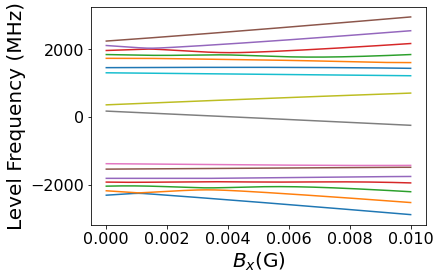

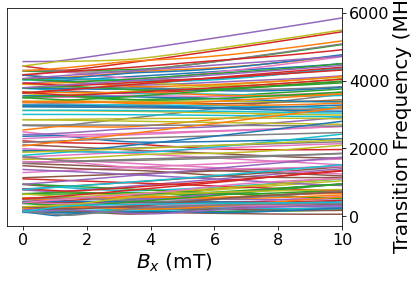

In [5]:
for i,x in enumerate(xs):
    B = Bu*x            
    HG = ground.calcH(B)
    #get the eigen frequencies and vectors at this B field
    FG,VG = ground.getEigFreq(HG)
    F[i,:]=FG*1E3
    for j in range(3):
        Fpx[i,:,j]= ground.firstOrderEnergySensitivity(VG,A[j])#+ground.firstOrderEnergySensitivity(VG,Ay)#x = 
    Fppx[i,:] = ground.curvatureCalculation(A[0],A[1],A[2],VG,FG,indiv=False).T

plt.plot(xs,F)
plt.xlabel("$B_{x}$(G)")
plt.ylabel("Level Frequency (MHz)")
plt.savefig("../images/Pr_level.pgf",bbox_inches='tight')
print("Es:", F[-1,:])

plt.show()
plt.close()


Ts = spin.eachElemFunc(F,F,ax=1)
Tds=spin.eachElemFunc(Fpx,Fpx,ax=1)
Tdds=spin.eachElemFunc(Fppx,Fppx,ax=1)

#fig = plt.figure(figsize=(10,10))

#Clip to only single transition direction
half=np.squeeze(np.argwhere(np.sign(Ts[0,:])==1))#int((ground.dim**2)/2)-1
Ts=Ts[:,half]
Tds=Tds[:,half]
Tdds=Tdds[:,half,:,:]


plt.plot(xs*1E3,Ts)
plt.xlim([None,Bf*1E3])
plt.xlabel("$B_{x}$ (mT)")
plt.ylabel("Transition Frequency (MHz)")

plt.annotate(r"$\pm\frac{1}{2}\rightarrow\pm\frac{5}{2}$",(-10,28),(-15,29),fontsize='large')
plt.annotate(r"$\pm\frac{3}{2}\rightarrow\pm\frac{5}{2}$",(-10,18),(-15,19),fontsize='large')
plt.annotate(r"$\pm\frac{1}{2}\rightarrow\pm\frac{3}{2}$",(-10,12),(-15,11),fontsize='large')
plt.annotate("Spin Flip",(-50,1),(-15,5),fontsize='large')

#plt.plot([732,732],[0,50],'--')
ax=plt.gca()
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
plt.savefig("../images/Pr_trans.pgf",bbox_inches='tight')

plt.show()
plt.close()

print()

In [6]:
#fig = plt.figure(figsize=(10,10))
slc=slice(4,-1)
#slc=slice(0,-1)
numr=np.gradient(Ts[slc],axis=0)/(Bf*10)
calc = Tds[slc]

#U@V
vecTimes=lambda U,V: np.squeeze(np.einsum('mr,ndr->nd',U,V))
#U.T@V@U
tenTimes=lambda U,V: np.squeeze(np.einsum("mr,ndrr,rm->nd",U.T,V,U))
proj= vecTimes(Bu.T,calc)#calc@unit
xt = xs[slc]

calcdd=(Tdds[slc,:,:,:])
projdd=tenTimes(Bu,calcdd)

error=0.01
dB=Bu*error*xt
print(dB.shape)
T2inv=vecTimes(dB.T,calc)+tenTimes(dB,calcdd)#calcdd*error*calcdd)/60/60
T2=1/(T2inv*np.pi)/60/60
#raise ValueError("Stop you've Violated the law!!!")

(3, 495)


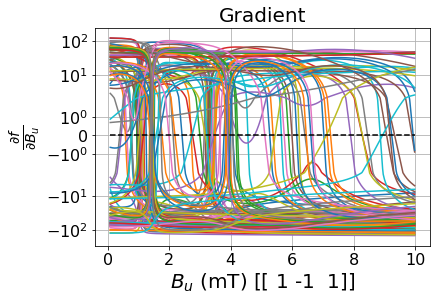

C:\Users\neb16\AppData\Roaming\Python\Python39\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\neb16\AppData\Roaming\Python\Python39\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


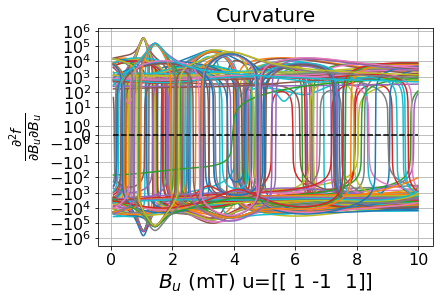

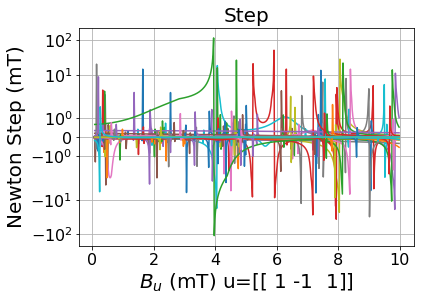

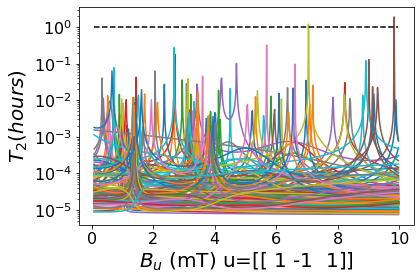

In [7]:

#plt.gca().set_prop_cycle(None)
plt.title("Gradient")
plt.plot(xt*1E3,proj)
#plt.plot(xt*1E3,(numr),'*')
plt.plot(xt*1E3,np.zeros_like(xt),'k--')
plt.xlabel(r"$B_{u}$ (mT) %s"%Bu.T)
plt.ylabel(r"$\frac{\partial f}{\partial B_{u}}$")
plt.yscale("symlog")
plt.grid()
plt.show()
plt.close()


plt.plot(xt*1E3,projdd)
plt.plot(xt*1E3,np.zeros_like(xt),'k--')
#plt.plot(xt*1E3,(numrd),'*')
plt.xlabel(r"$B_{u}$ (mT) u=%s"%Bu.T)
plt.ylabel(r"$\frac{\partial^2 f}{\partial B_{u}\partial B_{u}}$")

plt.title("Curvature")
plt.yscale('symlog')

plt.grid()
plt.show()
plt.close()
#fig = plt.figure(figsize=(10,10))

#starts=np.tile(xt,(calc.shape[1],1)).T
C=1/projdd
plt.plot(xt*1E3,-proj*C)
plt.grid()
plt.title("Step")
plt.yscale('symlog')
plt.xlabel(r"$B_{u}$ (mT) u=%s"%Bu.T)
plt.ylabel("Newton Step (mT)")
plt.show()
plt.close()

plt.plot(xt*1E3,np.abs(T2/np.pi))
plt.plot(xt*1E3,np.ones_like(xt),'k--')
plt.yscale('log')
plt.xlabel(r"$B_{u}$ (mT) u=%s"%Bu.T)
plt.ylabel(r"$T_{2}(hours)$")
plt.show()
plt.close()


#raise ValueError("Stop you've Violated the law!!!")

In [8]:
#@dask.delayed
def singleLoop(B):
    #print(params,flush=True)
    #global ground
    #convert spherical Magnetic field to cartesian coords.
    #B = np.matrix([X,Y,Z]).T
    #Calculate our hamiltonian at this B Field
    HG = ground.calcH(B)#Hcalc(B)#ground.H+ground.nuclearZeeman(B)#/spin.muN

    #get the eigen frequencies and vectors at this B field
    FG,VG = ground.getEigFreq(HG)
    F=FG*1E3
    
    Fp = []
    #OS = np.zeros((ground.dim,3),dtype = np.csingle)
    for l in range(3):
        v = ground.firstOrderEnergySensitivity(VG,A[l])
        Fp.append(v)
    Fp = np.array(Fp).T
    #Fpp = ground.curvatureCalculation(As[0],As[1],As[2],VG,FG,indiv=False).T#*spin.muN
    Fpp = ground.curvatureCalculationNaive(A[0],A[1],A[2],VG,FG,indiv=False).T#*spin.muN
    
    return (F,Fp,Fpp)
#@dask.delayed

def freqs(B):
    
    HG = Hcalc(B.T)#ground.H+ground.nuclearZeeman(B)#/spin.muN

    #get the eigen frequencies and vectors at this B field
    FG,VG = ground.getEigFreq(HG)
    F=FG*1E3
    return F
def sweep(Bs):
    F=np.zeros((len(Bs),ground.dim))
    Fp=np.zeros((len(Bs),ground.dim,3),dtype = np.csingle)
    Fpp=np.zeros((len(Bs),ground.dim,3,3),dtype = np.csingle)

    for i in range(Bs.shape[0]):
        F[i,:],Fp[i,:],Fpp[i,:] = singleLoop(Bs[i,:].T)
    return spin.eachElemFunc(F,F,ax=1),spin.eachElemFunc(Fp,Fp,ax=1),spin.eachElemFunc(Fpp,Fpp,ax=1)

def multiSweep(Bs):
    #if __name__ == '__main__':
    F=np.zeros((len(Bs),ground.dim))
    Fp=np.zeros((len(Bs),ground.dim,3),dtype = np.csingle)
    Fpp=np.zeros((len(Bs),ground.dim,3,3),dtype = np.csingle)
    with Pool() as pool:
        #F,Fp,Fpp=pool.map(ground.calcBOptParams,Bs)
        for i,result in enumerate(pool.map(ground.calcBOptParams,Bs)):#range(Bs.shape[0]):
            F[i,:],Fp[i,:],Fpp[i,:]=result

    return spin.eachElemFunc(F,F,ax=1),spin.eachElemFunc(Fp,Fp,ax=1),spin.eachElemFunc(Fpp,Fpp,ax=1)

In [9]:
np.set_printoptions(threshold=np.inf)

pts = 20

#ps= -1
#pe = 1
Bxi=np.linspace(-Bf,0,pts)
Byi = np.linspace(-Bf,Bf,pts)
#Byi = Bxi
Bzi = Byi

Bsi = np.array(np.meshgrid(Bxi,Byi,Bzi)).reshape(3,-1).T

half=int(Bsi.shape[0]/2)
Bnysm=Bsi[half:,:]#np.unique(np.hstack((Bsi,-1*Bsi)))
Bnysm=Bsi
#Bx=Bnysm[:,0].reshape(pts,pts,pts)
#,By,Bz = np.meshgrid(,Bnysm[:,1],Bnysm[:,2])
Bx,By,Bz=np.meshgrid(Bxi,Byi,Bzi)
#print(Bsi[:half,:],-1*Bsi[half:,:])

print(Bx.flatten().shape)

#raise ValueError("Stop you've Violated the law!!!")

(8000,)


In [10]:
#T,Td,Tdd=sweep(Bnysm)
#T,Td,Tdd=multiSweep(Bnysm)
#print(Bnysm[0,:])
#from multiprocessing import Pool
from pathos.multiprocessing import ProcessingPool as Pool
from functools import partial
import inspect

#def parallel_task(func, iterable, *params):

def parallel_task(func, iterable, *params):
    print(params)
    with open(f'./tmp_func.py', 'w') as file:
        file.write(inspect.getsource(func).replace(func.__name__, "task"))
        
    from tmp_func import task

    if __name__ == '__main__':
        print(params)
        func = partial(task, params)
        print(func)
        #pool = Pool(processes=8)
        with Pool() as pool:
            res = pool.map(func, iterable)
        return res
    else:
        raise "Not in Jupyter Notebook"
   
#from multiprocessing.pool import ThreadPool
#
#ground.runMultiThreadedSweep(Bnysm.T)
# print(ground.calcBOptParams(Bnysm[0,:].T))
#with Pool() as pool:
#    F,Fp,Fpp=pool.map(ground.calcBOptParams,Bnysm)
#print(F)
#def add(x,y):
#    return x+y
#x=[0,1,2,4]
#y=[4,5,6,7]

#with Pool() as p:
#    print(p.map(add,x,y))

#res=parallel_task(singleLoop,Bnysm,ground)

#print(res)
#     F,Fp,Fpp=res.get()
T,Td,Tdd=multiSweep(Bnysm)
#T,Td,Tdd=sweep(Bnysm)
#T,Td,Tdd=ground.runMultiThreadedSweep(Bnysm)


In [11]:
%%script false
%timeit multiSweep(Bnysm)
%timeit sweep(Bnysm)


Couldn't find program: 'false'


In [12]:
#%%script false
#print(res)
#print(T.shape)
#print(Bx.shape)
error=0.01
dB=Bsi.T*error
#print(dB.shape)

class T2calc():
    def __init__(self):
        from numpy import squeeze,einsum,pi
        self.vecTimes=lambda U,V: squeeze(einsum('r,dr->d',U,V))
        self.tenTimes=lambda U,V: squeeze(einsum("r,drr,r->d",U.T,V,U))
        self.pi=pi
        self.t=0
    def __call__(self,dB,Td,Tdd):
        T2inv=self.vecTimes(dB.T,Td)+self.tenTimes(dB,Tdd)#calcdd*error*calcdd)/60/60
        return (T2inv*self.pi)/60/60
    def single(self,dB,Td,Tdd):
        t=self.t
        T2inv=dB.T@Td[t,:]+dB.T@Tdd[t,:]@dB
        return 1/(T2inv*self.pi)/60/60
    def NewtonStep(self,Td,Tdd):
        t=self.t
        v=Td[t,:]
        C=np.linalg.inv(Tdd[t,:])
        print(v)
        print(C)  
        return C@Td
    
# def T2calc(dB,Td,Tdd):
#     #print(dB.shape,Td.shape,Tdd.shape)
#     dB=dB.T
#     Td=Td.T
#     Tdd=Tdd.T
#     return dB.shape,Td.shape,Tdd.shape
#     #T2inv=dB.T@Td+dB.T@Tdd@dB
#     #return 1/(T2inv)/60/60
# #def T2calc(dB,Td,Tdd):  
#    from numpy import squeeze,einsum,pi

vecTimes=lambda U,V: np.squeeze(np.einsum('mr,ndr->nd',U,V))
tenTimes=lambda U,V: np.squeeze(np.einsum("mr,ndrr,rm->nd",U.T,V,U))

def T2alt(dB,Td,Tdd):
    T2inv=vecTimes(dB.T,Td)+tenTimes(dB,Tdd)#calcdd*error*calcdd)/60/60
    return 1/(T2inv*np.pi)/60/60
def T2Multi(dB,Td,Tdd):
    calc=T2calc()
    calc.t=2
    with Pool() as pool:
        T2 = pool.map(calc.single, dB.T,Td,Tdd)
    return np.vstack(T2)

calc=T2calc()
calc.t=2
calc.NewtonStep(Td[:,0],Tdd[:,0])


#T2=T2Multi(dB,Td,Tdd)
#T2=T2alt(dB,Td,Tdd)

#print(T2.shape,T2A.shape)
#print(T2.T)
#print(T2A.T)

LinAlgError: Singular matrix

In [ ]:
#%%script false
%timeit T2Multi(dB,Td,Tdd)
%timeit T2alt(dB,Td,Tdd)


2.35 s ± 49.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


C:\Users\neb16\AppData\Local\Temp/ipykernel_11888/774271000.py:40: RuntimeWarning: divide by zero encountered in true_divide
  return 1/(T2inv*np.pi)/60/60
C:\Users\neb16\AppData\Local\Temp/ipykernel_11888/774271000.py:40: RuntimeWarning: invalid value encountered in true_divide
  return 1/(T2inv*np.pi)/60/60


In [ ]:
t=2
val=(np.abs(T2[:,t]))
#val=np.abs(T2)
#fill=np.zeros(half)
valp=np.log10(val)#np.log10(np.hstack([fill,val]))

fig = go.Figure(data=go.Isosurface(
    x=Bx.flatten(),
    y=By.flatten(),
    z=Bz.flatten(),
    value=valp,
    opacity=0.6,
    isomin=None,
    isomax=None,
    surface_count=20, # number of isosurfaces, 2 by default: only min and max
    colorbar_nticks=20, # colorbar ticks correspond to isosurface values
    caps=dict(x_show=False, y_show=False)
    ))
fig.show()